IMT 2200 - Introducción a Ciencia de Datos<br>
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

---

## Tarea 01 – Cargando y Analizando Datos

- **Fecha de Entrega:** martes 26 de agosto de 2025, a las 23:59.
- 
**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en l emódulo de Tara 01 habilitado en Canvas.




## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tara.

- Deben hacer sus consultas y comentarios sobre la Tarea a traves del canal de Tareas en eo del curso en Canvas.os.
cteriza.

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

Para esta tarea, tendremos como objetivo comprender cómo han cambiado los juegos de mesa en los últimos 40 años. Específicamente queremos saber qué tipos de juegos se han vuelto más comunes hoy en día y qué los caracteriza.

### 1.3 Recomendaciones
- Utiliza las librerías sugeridas en el notebook o justifica brevemente si incorporas otras.
- Revisa que todas las celdas se ejecuten en orden, desde el inicio, sin errores.
- Comenta tu código para explicar qué hace cada sección relevante.
- Asegúrate de que las visualizaciones sean fáciles de interpretar y tengan títulos y etiquetas adecuados.

## 2. Datos

Estaremos utilizando información extraída desde [BoardGameGeek.com](https://boardgamegeek.com/), una plataforma para aficionados de los juegos de mesa, que permite a sus usuarios registrar, calificar e intercambiar sus juegos favoritos. Actualmente, BGG es una de las bases de datos más extensa y diversa de juegos de mesa.

El dataset con el que trabajaremos consiste en un grupo de archivos CSV que contienen información sobre más de 100.000 juegos de mesa almacenados en la plataforma. Este puede descargarse directamente desde el siguiente enlace: https://www.kaggle.com/datasets/mshepherd/board-games Para descargar los datos, haga click en el botón de **Download**, donde podrá descargar los archivos como `.zip`, o bien utilizar la API de Kaggle.

Para el desarrollo de esta tarea, solo utilizaremos los archivos con el prefijo `bgg_`.

**Si utiliza la API de Kaggle para descargar los datos, deje el código utilizado en la siguiente celda:**

In [33]:
# Necesitamos la librería de kagglehub para poder descargar el dataset.
%pip install kagglehub 

# Descarga de datos desde Kaggle
import kagglehub

# Download latest version
path_dataset_games = kagglehub.dataset_download("mshepherd/board-games")

print("Path to dataset files:", path_dataset_games)

Note: you may need to restart the kernel to use updated packages.
Path to dataset files: C:\Users\pluta\.cache\kagglehub\datasets\mshepherd\board-games\versions\13


### 2.1 Librerías

Para esta tarea recomendamos al menos usar las librerías indicadas en la siguiente celda del Notebook. Puede agregar otras si lo estima conveniente para responder de mejor forma las preguntas de la Tarea.

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os # Para evitar problemas de compatibilidad con Windows y otros OS.
from pathlib import Path # Para calcular el tamaño de los archivos, necesitamos su path.

## 3. Desarrollo

Para cada una de las siguientes preguntas o actividades incluya una o más celdas de código y Markdown con las respuestas o comentarios necesarios para contestar la pregunta o lograr la actividad. Agregue sus celdas a continuación de cada pregunta para que el Notebook quede ordenado.

En el caso de gráficos, figuras o tablas, asegúrese que todas tengan título, etiquetas en los ejes o haya claridad de los contenidos.

### 3.1 DataFrame unificado (1 punto)

Vamos a cargar en un DataFrame los datos de juegos guardados en el documento `bgg_GameItem.csv`. Al inspeccionar nuestros datos, podemos notar que los valores de ciertas comunas vienen "codificados" con ID. Para comenzar, vamos a juntar la información de los distintos archivos descargados.

**a) (0.8 pts)** Genere un DataFrame único con toda la información de cada juego, incluyendo: nombres de artistas y diseñadores involucrados, mecánicas, categorías, tipo, familia y editorial. Guarde este DataFrame en un nuevo archivo CSV.

In [35]:
# Usamos el path anterior para cargar el DF desde el CSV.
gameitem_path = os.path.join(path_dataset_games, "bgg_GameItem.csv")
df_bgg_gameitem = pd.read_csv(gameitem_path)

print("Revisamos el DF con .info():")
print(df_bgg_gameitem.info(), '\n')

# Miramos si existen duplicados en el DF original, si existen los eliminaremos.
# Generado con AI. Prompt: dime como printear la cantidad de duplicados del df
print(df_bgg_gameitem.duplicated().sum(), "duplicados en el DF original.")

Revisamos el DF con .info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113904 entries, 0 to 113903
Data columns (total 38 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   bgg_id               113904 non-null  int64  
 1   name                 113904 non-null  object 
 2   year                 104219 non-null  float64
 3   game_type            25830 non-null   object 
 4   designer             95653 non-null   object 
 5   artist               47872 non-null   object 
 6   publisher            113852 non-null  object 
 7   min_players          111966 non-null  float64
 8   max_players          108448 non-null  float64
 9   min_players_rec      111966 non-null  float64
 10  max_players_rec      108448 non-null  float64
 11  min_players_best     111966 non-null  float64
 12  max_players_best     108448 non-null  float64
 13  min_age              90641 non-null   float64
 14  min_age_rec          1126 non-null    f

Ahora, con el DF visible en la anterior celda, podemos seleccionar las columnas que queremos para generar el nuevo DF filtrado, y guardarlo en un nuevo fichero en formato CSV.

No se ha guardado la columna con los ids, porque no se ha pedido.

In [36]:
# Columnas que queremos en el nuevo DF.
cols_to_keep = ['artist', 'designer', 'publisher', 'mechanic', 'category', 'game_type', 'family', 'publisher']
df_bgg_gameitem_filtered = df_bgg_gameitem[cols_to_keep] # Nuevo DF filtrado.

# Generamos un nuevo fichero CSV con el nuevo DF guardado en la variable anterior.
# df_bgg_gameitem_filtered.to_csv('bgg_gameitem_filtered.csv', index=False)
path_to_save_csv_filtered = os.path.join(path_dataset_games, "bgg_GameItem_filtered.csv")
df_bgg_gameitem_filtered.to_csv(path_to_save_csv_filtered, index=False)

print('Número de filas y columnas del antiguo DF:', df_bgg_gameitem.shape, '\n')
print('Número de filas y columnas del nuevo DF:', df_bgg_gameitem_filtered.shape)

Número de filas y columnas del antiguo DF: (113904, 38) 

Número de filas y columnas del nuevo DF: (113904, 8)


**b) (0.2 pts)** ¿Cuánto espacio en disco ocupa este DataFrame? ¿Cuánto espacio en disco ocupan los documentos CSV separados? ¿A qué se debe esta diferencia? Comente.



Para la celda posterior, se ha usado AI para la conversión de KB a MB, como también para calcular la variable mem_bytes.
prompt1: si tengo una variable con el peso de un archivo como lo paso a mb pero dime la conversion desde 1kb a mb
prompt2: como puedo ver el tamaño de un DF, no me queda claro porque un dataframe se genera en memoria ram cierto?

In [37]:
# Calculamos el tamaño del fichero en bytes.
file_size = os.path.getsize(gameitem_path)
# print(f"El tamaño del archivo original {gameitem_path} es: {file_size} bytes \n")

# Hacemos la conversión de bytes a MB, recordemos que
# 1KB = 1024 bytes, por lo tanto, 1MB son 1KB * 1024, lo que nos da
# 1MB = 1024 * 1024 bytes.
file_size_mb = file_size / (1024 * 1024)

print(f"El tamaño del archivo {gameitem_path} es: {file_size_mb:.2f} MB \n")

# .memmory_usage() nos da el tamaño de cada columna en bytes, así que debemos
# sumar el tamaño de todas las columnas para obtener el tamaño total
# del DF, usamos .sum() para sumar el tamaño de todas las columnas en bytes.
mem_bytes = df_bgg_gameitem.memory_usage(deep=True).sum()

print(f'El tamaño del DF {gameitem_path} es: {mem_bytes} bytes \n')

mem_mb = mem_bytes / 1024**2
print(f'El tamaño del DF {gameitem_path} es: {mem_mb:.2f} MB \n')

El tamaño del archivo C:\Users\pluta\.cache\kagglehub\datasets\mshepherd\board-games\versions\13\bgg_GameItem.csv es: 15.33 MB 

El tamaño del DF C:\Users\pluta\.cache\kagglehub\datasets\mshepherd\board-games\versions\13\bgg_GameItem.csv es: 84415985 bytes 

El tamaño del DF C:\Users\pluta\.cache\kagglehub\datasets\mshepherd\board-games\versions\13\bgg_GameItem.csv es: 80.51 MB 



Ahora, hacemos el mismo cálculo pero para el DF y el CSV del dataset filtrado a partir del punto 3.1 a)

In [38]:
# Calculamos el tamaño del fichero en bytes.
gameitem_filtered_path = os.path.join(path_dataset_games, "bgg_GameItem_filtered.csv")
file_size = os.path.getsize(gameitem_filtered_path)
# print(f"El tamaño del archivo original {gameitem_path} es: {file_size} bytes \n")

# Hacemos la conversión de bytes a MB, recordemos que
# 1KB = 1024 bytes, por lo tanto, 1MB son 1KB * 1024, lo que nos da
# 1MB = 1024 * 1024 bytes.
file_size_mb = file_size / (1024 * 1024)

print(f"El tamaño del archivo {gameitem_filtered_path} es: {file_size_mb:.2f} MB \n")



# .memmory_usage() nos da el tamaño de cada columna en bytes, así que debemos
# sumar el tamaño de todas las columnas para obtener el tamaño total
# del DF, usamos .sum() para sumar el tamaño de todas las columnas en bytes.
mem_bytes = df_bgg_gameitem_filtered.memory_usage(deep=True).sum()

print(f'El tamaño del DF {gameitem_filtered_path} es: {mem_bytes} bytes \n')

mem_mb = mem_bytes / 1024**2
print(f'El tamaño del DF {gameitem_filtered_path} es: {mem_mb:.2f} MB \n')


El tamaño del archivo C:\Users\pluta\.cache\kagglehub\datasets\mshepherd\board-games\versions\13\bgg_GameItem_filtered.csv es: 6.91 MB 

El tamaño del DF C:\Users\pluta\.cache\kagglehub\datasets\mshepherd\board-games\versions\13\bgg_GameItem_filtered.csv es: 46496923 bytes 

El tamaño del DF C:\Users\pluta\.cache\kagglehub\datasets\mshepherd\board-games\versions\13\bgg_GameItem_filtered.csv es: 44.34 MB 



Hemos calculado el espacio utilizado tanto por los DF del dataset filtrado, como del no filtrado, lo mismo se ha calcualdo para los .CSV, están en los outputs de las celdas anteriores.

Como vemos, el tamaño de los archivos (ficheros), es mucho menor que el objeto DataFrame construido mediante la librería Pandas, esto se debe a que Pandas es una librería "de alto nivel", facilita el manejo de datos, pero para eso debe incluir relaciones entre los datos que en el .CSV no están. Construir un objeto DF cuesta memoria, se incluyen metadatos y se transforman algunos tipos de datos a otros (Pandas tiene su propio criterio de conversión para tratar los datos). A pesar de esto, Pandas ayuda mucho a manejar más cómodamente los datos.

Vale la pena destacar que el espacio que ocupan los .CSV es generalmente en la memoria no volátil, mientras que los objetos de tipo DF generalmente se almacenan en la memoria volátil (RAM).

### 3.2 Juegos publicados anualmente (1.5 puntos)


**a) (0.5 pts)** Limpie los datos para dejar solo aquellos que tienen valores válidos de año de publicación. Luego responda: ¿cuál es el rango de años con el que estamos trabajando? ¿Tienen sentido estos años?


Supondremos que el enunciado pide el DF no filtrado, el que tiene menos columnas, el que inicialmente cargamos del CSV descargado de Kaggle, ya que este contiene los años.

In [39]:
# Filtramos el DF para mantener solo las filas con año no nulo.
df_filtered_year = df_bgg_gameitem.loc[df_bgg_gameitem['year'].notna()].copy()

# Convertimos el tipo de dato de la columna 'year' a entero, por si
# existieran valores no enteros.
df_filtered_year['year'] = df_filtered_year['year'].astype(int)

# Revisamos el DF.
df_filtered_year.info()

year_min = df_filtered_year['year'].min()
year_max = df_filtered_year['year'].max()
print(f"\n\n Rango de años (tras eliminar NaN): {year_min}–{year_max}")

<class 'pandas.core.frame.DataFrame'>
Index: 104219 entries, 0 to 113903
Data columns (total 38 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   bgg_id               104219 non-null  int64  
 1   name                 104219 non-null  object 
 2   year                 104219 non-null  int64  
 3   game_type            24800 non-null   object 
 4   designer             89416 non-null   object 
 5   artist               45953 non-null   object 
 6   publisher            104175 non-null  object 
 7   min_players          102718 non-null  float64
 8   max_players          99699 non-null   float64
 9   min_players_rec      102718 non-null  float64
 10  max_players_rec      99699 non-null   float64
 11  min_players_best     102718 non-null  float64
 12  max_players_best     99699 non-null   float64
 13  min_age              84317 non-null   float64
 14  min_age_rec          1124 non-null    float64
 15  min_time             8

Se ha usado .loc, y luego el método .copy() para evitar la copia por referencia, que puede cambiar el DF original.

Se ha usado AI para consultar sobre el warning y como evitar cambios en la memoria por referencia.

#### Contexto del warning:

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_year['year'] = df_filtered_year['year'].astype(int)

Finalmente, podemos ver que se han filtrado los años con valores no válidos, y se ha transformado el valor de la columna 'year' a entero, pero podemos ver que el año con valor menor está en -3500, lo que en muchos contextos no es válido, se podría filtrar para los años de cierta fecha en adelante, pero como en el siguiente punto (b) se hará con los años 1980 y 2025, no lo he realizado aquí, ya que el código es análogo y me parece demasiado arbitrario poner un año determinado para filtrar.

**b) (0.5 pts)** Seleccione solamente los juegos entre los años 1980 y 2025. Luego grafique la cantidad de juegos publicados por año. ¿Cómo es esta tendencia? Comente.

Igual que antes, utilizamos .loc y luego .copy(), para copiar el valor del objeto por valor, no por referencia en memoria, para evitar cambios no deseados.

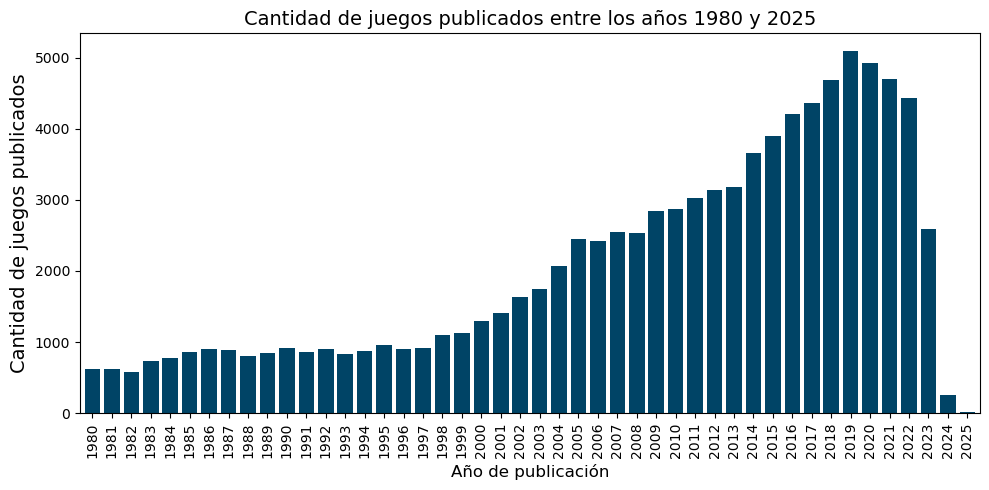

Total de publicaciones de juegos entre los años 1980 y 2025: 93019


In [40]:
filter_of_years = (df_filtered_year['year'] >= 1980) & (df_filtered_year['year'] <= 2025)
df_1980_2025 = df_filtered_year.loc[filter_of_years].copy()

# Con el método .value_counts() obtenemos la cantidad de juegos para cada año en la serie,
# y con .sort_index() ordenamos los años de forma ascendente.
counts_per_year = df_1980_2025['year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
counts_per_year.plot(kind='bar', color='#004466', width=0.8)
plt.title('Cantidad de juegos publicados entre los años 1980 y 2025', fontsize=14)
plt.xlabel('Año de publicación', fontsize=12)
plt.ylabel('Cantidad de juegos publicados', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Total de publicaciones de juegos entre los años 1980 y 2025: {counts_per_year.sum()}")


In [41]:
# Por separado, mostramos la cantidad de juegos publicados por año:
print(counts_per_year)

year
1980     617
1981     623
1982     586
1983     733
1984     777
1985     855
1986     899
1987     889
1988     803
1989     846
1990     912
1991     867
1992     897
1993     827
1994     880
1995     957
1996     903
1997     919
1998    1093
1999    1125
2000    1299
2001    1403
2002    1637
2003    1742
2004    2064
2005    2448
2006    2419
2007    2552
2008    2538
2009    2843
2010    2878
2011    3028
2012    3141
2013    3179
2014    3663
2015    3898
2016    4209
2017    4362
2018    4692
2019    5087
2020    4926
2021    4693
2022    4436
2023    2597
2024     261
2025      16
Name: count, dtype: int64


Podemos ver que cerca del año 2000, entre las fechas estudiadas, hay una tendencia a que la cantidad de publicaciones de juegos por año aumente, pero desde el año 2020 hacia adelante se invierte el fenómeno, hay un declive de la cantidad de publicaciones de juegos por año. Esto puede ser un fenómeno causado por diferentes factores, o puede ser un error en los datos de esos años. Tiene sentido que en el año 2025 los datos estén incompletos, pero en el año 2024 se nota un declive de publicaciones demasiado pronunciado en relación a los datos de años anteriores, es un cambio muy abrupto.

**c) (0.5 pts)** ¿Entre qué años hubo un mayor aumento de publicación de juegos de mesa según los registros de BGG?

Se ha usado AI para la celda posterior, porque no encontré fácilmente en la documentación como encontrar la diferencia de un determinado atributo.
- prompt: como puedo ver la diferencia entre valores para un mismo año en la celda anterior? no quiero nada complicado, debe existir un metodo para poder ver la diferencia de forma simple ordenada

De la variable de tipo Series anterior, llamada counts_per_year, podemos tomar la diferencia entre los valores de indices consecutivos, por ejemplo, para el índice del año 2010 y 2011, se calcula la diferencia entre los valores de esos años, esto es, la diferencia de publicaciones entre esos años.

Luego, con delta.max() obtenemos el mayor cambio, y con delta.idxmax() hallamos el índice en el que ocurre ese mayor cambio, que resulta ser el año buscado.

In [42]:
delta = counts_per_year.diff()
max_increase = delta.max()
max_year = delta.idxmax()

print(f"El mayor aumento de publicaciones ocurre entre los años: {int(max_year-1)} - {int(max_year)}\n")
print(f"El aumento es de: {int(max_increase)} juegos")

El mayor aumento de publicaciones ocurre entre los años: 2013 - 2014

El aumento es de: 484 juegos


### 3.3 Análisis de duración y complejidad (1.5 puntos)

Si bien hay muchas posibles características que podemos explorar para los juegos de mesa, esta vez nos centraremos en el tiempo de juego y la complejidad. En esta sección queremos comprender si se ha modificado notablemente la duración promedio y la percepción de complejidad de los juegos de mesa a través de los años.

**a) (0.3 pts)** Inspecciones y filtre los datos que tengan valores válidos para: tiempo mínimo de juego, tiempo máximo de juego y complejidad. En el caso de que existan "outliers", puede descartarlos, cosiderando un rango razonable para las variables anteriores. Justifique su desición.

Partimos del DF con las fechas filtradas y limpiadas anteriormente.

He usado AI.
Prompt: dime como puedo ver todas las cols de una vez, describe recorta, intenta hacerlo sin tanto codigo.

In [43]:
# Mostramos todas las columnas del DF
with pd.option_context('display.max_columns', None):
    display(df_1980_2025.describe())

,bgg_id,year,min_players,max_players,min_players_rec,max_players_rec,min_players_best,max_players_best,min_age,min_age_rec,min_time,max_time,cooperative,compilation,rank,num_votes,avg_rating,stddev_rating,bayes_rating,complexity,language_dependency,bga_id,dbpedia_id,luding_id,spielen_id,wikidata_id,wikipedia_id
count,93019.000000,93019.000000,92191.000000,89872.000000,92191.000000,89872.000000,92191.000000,89872.000000,78526.000000,1060.000000,79227.000000,7.922700e+04,5987.0,833.0,22951.000000,74431.000000,74431.000000,60684.000000,23376.000000,43387.000000,811.000000,0.0,0.0,0.0,0.0,0.0,0.0
mean,166629.441232,2009.439287,2.014665,6.977557,2.020544,6.954903,2.062414,6.924470,9.651275,10.006776,49.464993,1.490142e+03,1.0,1.0,11998.241732,293.264675,6.240424,1.513376,5.687168,1.911683,2.140736,NaN,NaN,NaN,NaN,NaN,NaN
std,124875.777180,10.993398,0.811073,53.850327,0.817420,53.838705,0.863343,53.840919,7.912080,2.738265,607.949875,2.545099e+05,0.0,0.0,7029.095961,2284.156171,1.552529,0.613715,0.362253,0.825894,1.190597,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,1980.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.045455,1.000000,1.000000e+00,1.0,1.0,1.000000,1.000000,1.000000,0.000500,4.438280,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,36192.500000,2004.000000,2.000000,4.000000,2.000000,4.000000,2.000000,3.000000,8.000000,8.083333,15.000000,2.000000e+01,1.0,1.0,5901.500000,2.000000,5.360000,1.190358,5.511038,1.000000,1.015038,NaN,NaN,NaN,NaN,NaN,NaN
50%,157770.000000,2012.000000,2.000000,4.000000,2.000000,4.000000,2.000000,4.000000,10.000000,10.047727,30.000000,4.000000e+01,1.0,1.0,11909.000000,9.000000,6.287360,1.462480,5.544300,2.000000,1.900000,NaN,NaN,NaN,NaN,NaN,NaN
75%,282294.000000,2018.000000,2.000000,6.000000,2.000000,6.000000,2.000000,6.000000,12.000000,12.000000,60.000000,6.000000e+01,1.0,1.0,18049.000000,50.000000,7.142860,1.770355,5.673720,2.435900,3.081140,NaN,NaN,NaN,NaN,NaN,NaN
max,392146.000000,2025.000000,50.000000,11299.000000,50.000000,11299.000000,50.000000,11299.000000,2017.000000,20.541667,157680.000000,6.307200e+07,1.0,1.0,24480.000000,119186.000000,10.000000,4.500000,8.423300,5.000000,4.983333,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
initial_count = len(df_1980_2025)

# Hacemos un filtro para las columnas no nulas en un objeto Series.
cols_not_null = (
    df_1980_2025['year'].notna() & # No necesario, pero lo agregamos igualmente.
    df_1980_2025['min_time'].notna() &
    df_1980_2025['max_time'].notna() &
    df_1980_2025['complexity'].notna()
)

#print(type(cols_not_null))

# Otro filtro para que los valores tengan sentido.
cols_filter = (
    (df_1980_2025['min_time'] > 0) &
    (df_1980_2025['max_time'] > 0) &
    (df_1980_2025['max_time'] > df_1980_2025['min_time']) # El tiempo máximo debe ser mayor al mínimo.
)

# De nuevo, usamos .loc y .copy luego de aplicar el filtro, para copiar el DF a una nueva variable.
df_1980_2025_filtered_complexity = df_1980_2025.loc[cols_not_null & cols_filter].copy()

# Pasamos las variables del dataset a int, en caso de que no lo estén.
df_1980_2025_filtered_complexity['year'] = df_1980_2025_filtered_complexity['year'].astype(int)
df_1980_2025_filtered_complexity['min_time'] = df_1980_2025_filtered_complexity['min_time'].astype(int)
df_1980_2025_filtered_complexity['max_time'] = df_1980_2025_filtered_complexity['max_time'].astype(int)
df_1980_2025_filtered_complexity['complexity'] = df_1980_2025_filtered_complexity['complexity'].astype(int)

print(f"Cantidad de filas originales: {initial_count} \n")
print(f"Cantidad de filas luego de filtrar: {len(df_1980_2025_filtered_complexity)} \n")

Cantidad de filas originales: 93019 

Cantidad de filas luego de filtrar: 14630 



Ahora, para eliminar los outliers y establecer un rango razonable para las variables anteriores, vamos a hacer un análisis estadístico básico de los datos, a través de los quartiles.

Primero, usamos describe() para poder ver los datos.

In [45]:
with pd.option_context('display.max_columns', None):
    display(df_1980_2025_filtered_complexity.describe())

,bgg_id,year,min_players,max_players,min_players_rec,max_players_rec,min_players_best,max_players_best,min_age,min_age_rec,min_time,max_time,cooperative,compilation,rank,num_votes,avg_rating,stddev_rating,bayes_rating,complexity,language_dependency,bga_id,dbpedia_id,luding_id,spielen_id,wikidata_id,wikipedia_id
count,14630.000000,14630.000000,14621.000000,14581.000000,14621.000000,14581.000000,14621.000000,14581.000000,14021.000000,526.000000,14630.000000,14630.00000,1576.0,263.0,8100.000000,14378.000000,14378.000000,13535.000000,8303.000000,14630.000000,347.000000,0.0,0.0,0.0,0.0,0.0,0.0
mean,244985.764662,2016.888380,1.881609,6.339003,1.897408,6.274878,2.036933,6.175982,10.581057,10.630412,41.816815,122.77177,1.0,1.0,9768.966914,733.012936,6.969848,1.530272,5.774829,1.807109,2.325257,NaN,NaN,NaN,NaN,NaN,NaN
std,90130.080884,6.340686,0.740838,20.534235,0.760432,20.453913,0.897254,20.462821,2.981315,2.651510,76.056962,1003.92023,0.0,0.0,6546.944069,3761.102441,1.123431,0.498387,0.445579,0.798336,1.194731,NaN,NaN,NaN,NaN,NaN,NaN
min,3.000000,1980.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.045455,1.000000,2.00000,1.0,1.0,1.000000,1.000000,1.000000,0.025000,4.643180,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,192824.750000,2016.000000,1.000000,4.000000,1.000000,4.000000,2.000000,3.000000,8.000000,8.447321,15.000000,30.00000,1.0,1.0,4073.500000,10.000000,6.325477,1.253205,5.526395,1.000000,1.033680,NaN,NaN,NaN,NaN,NaN,NaN
50%,254503.500000,2018.000000,2.000000,4.000000,2.000000,4.000000,2.000000,4.000000,10.000000,11.500000,30.000000,60.00000,1.0,1.0,9080.000000,45.000000,6.996540,1.469140,5.579550,2.000000,2.181818,NaN,NaN,NaN,NaN,NaN,NaN
75%,314028.750000,2020.000000,2.000000,6.000000,2.000000,6.000000,2.000000,6.000000,13.000000,12.181818,45.000000,90.00000,1.0,1.0,14792.750000,209.000000,7.636132,1.743135,5.811390,2.000000,3.305632,NaN,NaN,NaN,NaN,NaN,NaN
max,391137.000000,2025.000000,15.000000,1000.000000,15.000000,1000.000000,15.000000,1000.000000,21.000000,17.573684,6000.000000,84000.00000,1.0,1.0,24480.000000,119186.000000,10.000000,4.500000,8.423300,5.000000,4.945205,NaN,NaN,NaN,NaN,NaN,NaN


Ahora, obtendremos los mismos datos que anteriormente, pero mejor organizados, tomaremos el valor mínimo y máximo del tiempo, y veremos sus quartiles, pero para la variable de la complejidad del juego no lo haremos, porque se puede ver en la casilla anterior que el mínimo es 1, el máximo es 5, y los quartiles 2 y 3 tienen un valor de 2 y algo más, por lo que no hay outliers para esa variable.

Tiempo mínimo y máximo:

In [46]:
# Tiempo mínimo del juego - Estadísticas:
min_time_min = df_1980_2025_filtered_complexity['min_time'].min()
min_time_max = df_1980_2025_filtered_complexity['min_time'].max()

min_time_q1 = df_1980_2025_filtered_complexity['min_time'].quantile(0.25)
min_time_median = df_1980_2025_filtered_complexity['min_time'].median()
min_time_mean = df_1980_2025_filtered_complexity['min_time'].mean()
min_time_q3 = df_1980_2025_filtered_complexity['min_time'].quantile(0.75)

print("Tiempo mínimo del juego - Estadísticas:")
print(f"\n min={min_time_min:.1f} \n max={min_time_max:.1f} \n Q1={min_time_q1:.1f} \
    \n Q2={min_time_median:.1f} \n Q3={min_time_q3:.1f} \n promedio={min_time_mean:.1f}")

print("--------------------------------\n")


# Tiempo máximo del juego - Estadísticas:
max_time_min = df_1980_2025_filtered_complexity['max_time'].min()
max_time_max = df_1980_2025_filtered_complexity['max_time'].max()

max_time_q1 = df_1980_2025_filtered_complexity['max_time'].quantile(0.25)
max_time_median = df_1980_2025_filtered_complexity['max_time'].median()
max_time_mean = df_1980_2025_filtered_complexity['max_time'].mean()
max_time_q3 = df_1980_2025_filtered_complexity['max_time'].quantile(0.75)
print("Tiempo máximo del juego - Estadísticas:")
print(f"\n min={max_time_min:.1f} \n max={max_time_max:.1f} \n Q1={max_time_q1:.1f} \
    \n Q2={max_time_median:.1f} \n Q3={max_time_q3:.1f} \n promedio={max_time_mean:.1f}")

Tiempo mínimo del juego - Estadísticas:

 min=1.0 
 max=6000.0 
 Q1=15.0     
 Q2=30.0 
 Q3=45.0 
 promedio=41.8
--------------------------------

Tiempo máximo del juego - Estadísticas:

 min=2.0 
 max=84000.0 
 Q1=30.0     
 Q2=60.0 
 Q3=90.0 
 promedio=122.8


Mirando los tipos de juegos, parece ser que el tiempo está en minutos, y podemos ver que el promedio de tiempo de los juegos ronda alrededor de una hora y, si bien hay juegos como Dungeons & Dragons, en donde las partidas pueden durar días, el valor máximo de 84.000 minutos es claramente un outlier, así que limitaremos el tiempo máximo de juego a 5 días, para incluir este tipo de juegos con partidas extensas, pero en otro contexto quizás se requiera tomar un valor máximo más cercano al promedio y la mediana de los datos, todo depende de lo que se quiera buscar, en este caso tomaremos arbitrariamente el máximo como 5 días, que son 7.200 minutos.

In [47]:
mask_minutes = df_1980_2025_filtered_complexity['max_time'] <= 7200
mask_order = df_1980_2025_filtered_complexity['min_time'] < df_1980_2025_filtered_complexity['max_time']

# Aplicamos el filtro
df_1980_2025_filtered_complexity = df_1980_2025_filtered_complexity.loc[mask_minutes & mask_order].copy()


before_total = len(df_1980_2025_filtered_complexity)
after_total = len(df_1980_2025_filtered_complexity)
print(f"Cantidad de filas antes del filtro: {before_total}")
print(f"Cantidad de filasdespués del filtro: {after_total}")

Cantidad de filas antes del filtro: 14619
Cantidad de filasdespués del filtro: 14619


Verificamos que se hayan aplicado los filtros correctamente:

In [48]:
with pd.option_context('display.max_columns', None):
    display(df_1980_2025_filtered_complexity.describe())

,bgg_id,year,min_players,max_players,min_players_rec,max_players_rec,min_players_best,max_players_best,min_age,min_age_rec,min_time,max_time,cooperative,compilation,rank,num_votes,avg_rating,stddev_rating,bayes_rating,complexity,language_dependency,bga_id,dbpedia_id,luding_id,spielen_id,wikidata_id,wikipedia_id
count,14619.000000,14619.000000,14610.000000,14570.000000,14610.000000,14570.000000,14610.000000,14570.000000,14011.000000,525.000000,14619.000000,14619.000000,1574.0,263.0,8092.000000,14367.000000,14367.000000,13524.000000,8295.000000,14619.000000,347.000000,0.0,0.0,0.0,0.0,0.0,0.0
mean,245044.121349,2016.892811,1.881725,6.340700,1.897331,6.276390,2.036756,6.177488,10.578974,10.619867,40.998016,104.842465,1.0,1.0,9768.933144,733.421522,6.969396,1.530052,5.774911,1.805801,2.325257,NaN,NaN,NaN,NaN,NaN,NaN
std,90076.599053,6.331750,0.741004,20.541831,0.760173,20.461492,0.896494,20.470415,2.980993,2.642975,50.311550,277.389657,0.0,0.0,6546.317389,3762.500132,1.123001,0.498212,0.445722,0.797008,1.194731,NaN,NaN,NaN,NaN,NaN,NaN
min,3.000000,1980.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.045455,1.000000,2.000000,1.0,1.0,1.000000,1.000000,1.000000,0.025000,4.643180,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,192829.500000,2016.000000,1.000000,4.000000,1.000000,4.000000,2.000000,3.000000,8.000000,8.446429,15.000000,30.000000,1.0,1.0,4073.500000,10.000000,6.325000,1.253218,5.526395,1.000000,1.033680,NaN,NaN,NaN,NaN,NaN,NaN
50%,254541.000000,2018.000000,2.000000,4.000000,2.000000,4.000000,2.000000,4.000000,10.000000,11.500000,30.000000,60.000000,1.0,1.0,9082.500000,45.000000,6.996290,1.469095,5.579470,2.000000,2.181818,NaN,NaN,NaN,NaN,NaN,NaN
75%,314036.000000,2020.000000,2.000000,6.000000,2.000000,6.000000,2.000000,6.000000,13.000000,12.181818,45.000000,90.000000,1.0,1.0,14792.750000,209.000000,7.635020,1.742308,5.811390,2.000000,3.305632,NaN,NaN,NaN,NaN,NaN,NaN
max,391137.000000,2025.000000,15.000000,1000.000000,15.000000,1000.000000,15.000000,1000.000000,21.000000,17.573684,1500.000000,6000.000000,1.0,1.0,24480.000000,119186.000000,10.000000,4.500000,8.423300,5.000000,4.945205,NaN,NaN,NaN,NaN,NaN,NaN


**b) (0.2 pts)** Veremos ahora si ha cambiado la duración promedio de los juegos de mesa en nuestro rango de años seleccionado. Primero, cree una nueva columna `avg_time` en el dataset con la duración promedio supuesta para cada juego.

Dado que cada juego tiene la duración mínima y máxima, para sacar el promedio no podemos usar directamente la mediana, necesitamos el promedio aritmético.

In [49]:
#avg_games_time = (df_1980_2025_filtered_complexity['min_time'] + df_1980_2025_filtered_complexity['max_time']) / 2.0
#print(type(avg_games_time))

#df_1980_2025_filtered_complexity['avg_time'] = avg_games_time
# Creamos la nueva columna 'avg_time'
df_1980_2025_filtered_complexity['avg_time'] = (
    df_1980_2025_filtered_complexity[['min_time','max_time']].mean(axis=1)
)

# Mostramos el DF con la nueva columna.
with pd.option_context('display.max_columns', None):
    display(df_1980_2025_filtered_complexity.head())

,bgg_id,name,year,game_type,designer,artist,publisher,min_players,max_players,min_players_rec,max_players_rec,min_players_best,max_players_best,min_age,min_age_rec,min_time,max_time,category,mechanic,cooperative,compilation,compilation_of,family,implementation,integration,rank,num_votes,avg_rating,stddev_rating,bayes_rating,complexity,language_dependency,bga_id,dbpedia_id,luding_id,spielen_id,wikidata_id,wikipedia_id,avg_time
2,3,Samurai,1998,5497,2,11883,"17,133,267,29,7340,7335,41,2973,4617,1391,8291...",2.0,4.0,2.0,4.0,3.0,3.0,10.0,9.733333,30,60,"1009,1035","2080,2040,2026,2846,2004,2002",NaN,NaN,NaN,"64960,10634,70711,60111,42,28732",NaN,NaN,252.0,15863.0,7.45913,1.19279,7.22869,2,1.006579,NaN,NaN,NaN,NaN,NaN,NaN,45.0
11,12,Ra,1999,5497,2,"20789,139382,64844,106255,11883","9,34,28620,267,29,23205,2973,8291,9881,42294,3...",2.0,5.0,2.0,5.0,3.0,4.0,12.0,9.772727,45,60,"1050,1082","2012,2923,2928,2922,2661,2004",NaN,NaN,NaN,"6471,66292,70711,3867,59705,62771,58,71084,60111",NaN,NaN,172.0,22003.0,7.53327,1.33845,7.35844,2,1.043750,NaN,NaN,NaN,NaN,NaN,NaN,52.5
12,13,CATAN,1995,"5497,5499",11,"12036,12382,13034,5442,26874,4959,11825,24191,...","37,267,4304,157,52686,7340,6784,46980,7162,906...",3.0,4.0,3.0,4.0,4.0,4.0,10.0,8.297571,60,120,"1021,1026","2072,2026,2902,2011,2915,2081,2876,2909,2008,2897",NaN,NaN,NaN,"7481,67874,68769,70360,77349,3,78198,11505",NaN,NaN,496.0,119186.0,7.10855,1.48869,6.93736,2,2.015679,NaN,NaN,NaN,NaN,NaN,NaN,90.0
17,18,RoboRally,1994,"5496,5497",14,"12500,28513,616,14508,18431,28512,11883,18317","13,267,23043,8,4871,51,7365",2.0,8.0,3.0,8.0,5.0,6.0,12.0,9.971429,45,120,"1059,1047,1031,1016","2689,2957,2676,2836,2011,2953,2876,2822,2020",NaN,NaN,NaN,"78568,25158,75031,22232,6924",NaN,NaN,532.0,23534.0,7.06528,1.54323,6.90882,2,2.714286,NaN,NaN,NaN,NaN,NaN,NaN,82.5
18,19,Wacky Wacky West,1991,5499,11,"35234,11883","133,10",2.0,4.0,3.0,4.0,4.0,4.0,9.0,NaN,30,45,"1055,1023,1029","2002,2017",NaN,NaN,NaN,NaN,NaN,NaN,3528.0,1885.0,6.27447,1.23732,5.86952,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.5


**c) (0.5 pts)** Grafique la duración promedio de juegos al año entre 1980 y 2025. ¿Existe alguna tendencia? Asegúrese de colocar las unidades correspondientes en sus ejes si es necesario. Comente sus resultados.

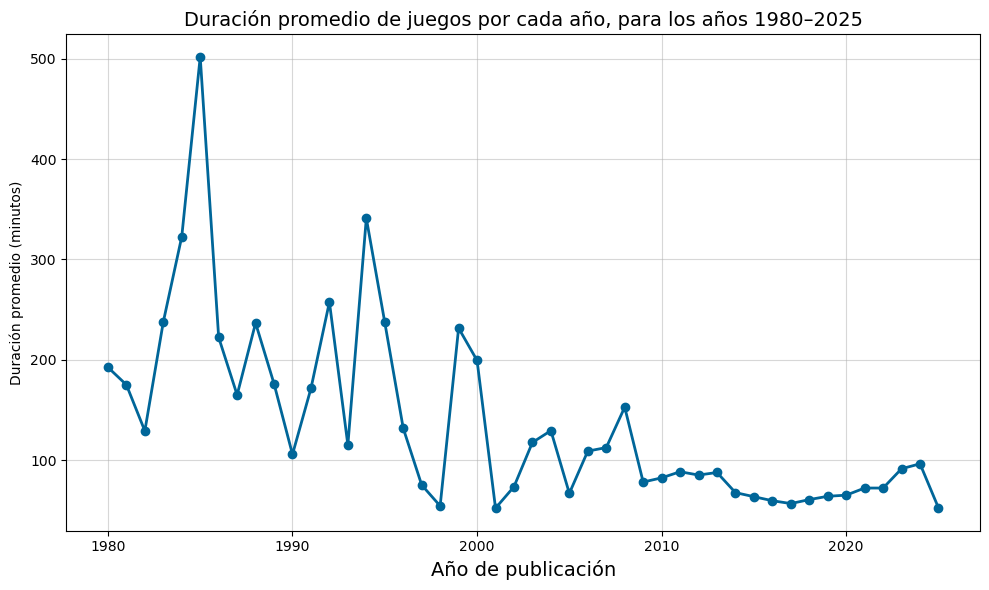

Duración promedio mínima/anual: 52.2 min; máxima/anual: 501.8 min


In [50]:
avg_time_by_year = (
    df_1980_2025_filtered_complexity.groupby('year', as_index=True)['avg_time']
    .mean()
    .sort_index()
)

plt.figure(figsize=(10,6))
plt.plot(avg_time_by_year.index, avg_time_by_year.values, marker='o', color='#006699', linewidth=2)
plt.title('Duración promedio de juegos por cada año, para los años 1980–2025', fontsize=14)
plt.xlabel('Año de publicación', fontsize=14)
plt.ylabel('Duración promedio (minutos)')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

# Para ver el min y max, se ha usado AI. Prompt: de la figura anterior necesito un print con el avg max y min en una linea
print(f"Duración promedio mínima/anual: {avg_time_by_year.min():.1f} min; máxima/anual: {avg_time_by_year.max():.1f} min")

Aquí podemos ver que la duración promedio de los juevos no es estable, ha subido y bajado a través de los años sin un cambio constante, podemos ver que en los primeros años del periodo estudiado se ven cambios más abruptos, pero con el pasar del tiempo vemos que esos cambios se estabilizan y no hay grandes diferencias entre la duración promedio para los juegos.

Recordemos que aquí estamos tomando el promedio primero evaluando el promedio aritmético que pusimos en una nueva columna y, luego, usando esa nueva col, tomamos el promedio de todos los juegos para cada año en base a esa col.

Lo que me parece muy destacable notar es que toda esta tendencia general a la baja se ve muy afectada por ls duración de juegos que se podrían considerar outliers, pero no quise sacarlos porque son juegos válidos, simplemente sus partidas duran algunos días, y en mi criterio no deberían ser escluídos del análisis al menos que estemos trabajando con otro tipo de contexto en mente, donde quisieramos sólo evaluar ciertos tipos de juegos de mesa.

**d) (0.5 pts)** Nos interesa saber si los juegos de mesa recientes son más complejos que aquellos publicados antes de los 2000. BoardGameGeek permite evaluar la complejidad (o "weight") de un juego en una escala de 1 a 5, siendo 1 un juego "liviano" o fácil de entender, y 5 un juego "pesado" o complejo. Primero, seleccione los juegos que han sido evaluados por al menos 100 usuarios. Luego grafique la complejidad promedio de los juegos según año. Responda: ¿ha cambiado la percepción de complejidad entre juegos entre 1980 y la actualidad?

Primero que nada, hacemos una limpieza de las columnas a utilizar, para asegurarnos de trabajar con datos válidos.

En la celda siguiente, tuve un error al aplicar el filtro, así que he usado AI.

prompt: por que aqui no puedo usar astyupe directamente en mi filtro (con código de celda adjunto)

output: Porque astype(int) convierte la columna a entero, pero no devuelve un valor booleano. El filtro necesita valores True/False para funcionar.
df_cleaned['num_votes'].astype(int) → convierte a int, pero no es una condición.
df_cleaned['num_votes'] >= 100 → compara y devuelve True/False.
Si quieres hacer todo en una línea, puedes usar:
O mejor aún, usar pd.to_numeric:
El astype solo cambia el tipo de dato, no crea una condición booleana. Los NaN no pueden convertirse a enteros.
Debes filtrar primero los NaN y luego hacer la comparación. Cambia el orden.

In [51]:
df_cleaned_votes = df_1980_2025_filtered_complexity.copy() # Cambiamos a un nombre más corto para este punto.

# Creamos un nuevo objeto de tipo Series que servirá como una máscara para filtrar luego las cols.
# Pero no limpiamos complexity, porque ya hemos filtrado en celdas anteriores esa col.
filter_votes = (
    (df_cleaned_votes['num_votes'].notna()) &
    (df_cleaned_votes['num_votes'] >= 100)
)

print(len(df_cleaned_votes), "Filas en el DF antes de filtrar por num_votes > 100\n")
df_cleaned_votes = df_cleaned_votes[filter_votes].copy()
print(len(df_cleaned_votes), "Filas en el DF después de filtrar por num_votes > 100\n")

14619 Filas en el DF antes de filtrar por num_votes > 100

5211 Filas en el DF después de filtrar por num_votes > 100



Creamos un objeto de tipo Series, para poder obtener los datos que queremos:
- Primero, agrupamos las entradas (filas) del DF por el año, así todas las entradas del mismo año caen en un mismo grupo

- Luego, de esa agrupación, seleccionamos la columna 'complexity'.

- Le sacamos la media, ya que es una métrica fácil de obtener para poder ver el promedio de la complejidad para cada año.

- Ordenamos el índice, que por default se ordena ascendentemente. 

In [52]:
complexity_by_year = (
    df_cleaned_votes
    .groupby('year', as_index=True)['complexity']
    .mean()
    .sort_index()
)

Ahora, sabemos que del objeto Series anterior, el índice es el year, que está ordenado, y los valores son la media (mean) de la complexity de los juegos en determinado año. Así que, le pasamos el índice y el valor a plt para poder graficar ordenadamente.

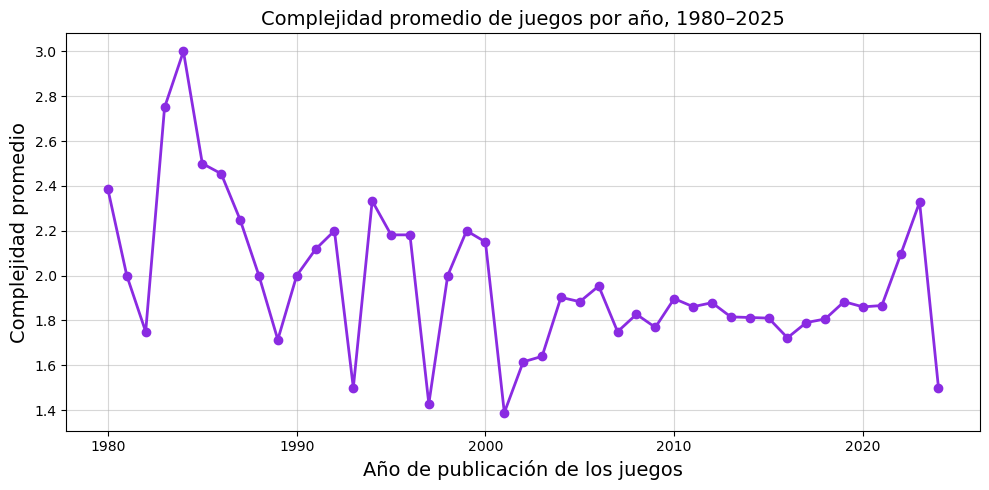

In [53]:
plt.figure(figsize=(10,5))
plt.plot(complexity_by_year.index, complexity_by_year.values, marker='o', color='#8A2BE2', linewidth=2)
plt.title('Complejidad promedio de juegos por año, 1980–2025', fontsize=14)
plt.xlabel('Año de publicación de los juegos', fontsize=14)
plt.ylabel('Complejidad promedio', fontsize=14)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

Sacamos el promedio para los juegos entre 1980-2000 y posterior al año 2000.

Generado con AI.
Prompt: En base a la celda anterior, dime como calculo el promedio para los años antes y despues del 2000 del df, y muestra la diferencia. HAZ EL CODIGO SIMPLE.

In [54]:
mean_pre_2000 = df_cleaned_votes.loc[df_cleaned_votes['year'] < 2000, 'complexity'].mean()
mean_post_2000 = df_cleaned_votes.loc[df_cleaned_votes['year'] >= 2000, 'complexity'].mean()
print(f"Complejidad promedio 1980–1999: {mean_pre_2000:.2f}")
print(f"Complejidad promedio 2000–2025: {mean_post_2000:.2f}")
print(f"Diferencia (post - pre): {mean_post_2000 - mean_pre_2000:+.2f}")

Complejidad promedio 1980–1999: 2.15
Complejidad promedio 2000–2025: 1.85
Diferencia (post - pre): -0.30


Se pueden ver cambios en la complejidad promedio en cada año tanto para años anteriores, como posteriores al 2000, pero el promedio de la complejidad está en declive, en la celda anterior se aprecia claramente que la complejidad entre los años 2000-2025 es menor que la existente entre los años 1980-1999.

### 3.4 Análisis de categorías comunes (2 puntos)

Existe una gran diversidad de categorías de juegos de mesa. Ahora nos concentraremos en un grupo específico de ellas, con el fin de analizar cómo a cambiado la cantidad de juegos de estas clases desde 1980 hasta hoy.

**a) (0.7 pts)** ¿Cuáles son las 5 categorías más comunes en los juegos del dataset? Muestre la cantidad de juegos que hay de cada una. Puede graficar estos valores, o bien, entregar un DataFrame con sus valores.

Asumiremos que no se ocupará el DF anterior con el filtrado de juegos que han sido votados más de 99 veces.

In [55]:
df_cleaned_category = df_1980_2025_filtered_complexity.copy() # Cambiamos a un nombre más corto para este punto.

# Creamos un nuevo objeto de tipo Series que servirá como una máscara para filtrar luego las cols.
# Pero no limpiamos complexity, porque ya hemos filtrado en celdas anteriores esa col.
filter_category = (
    (df_cleaned_category['category'].notna()) &
    (df_cleaned_category['category'].astype(str) != '')
)

print(len(df_cleaned_category), "Filas en el DF antes de filtrar por category válida\n")
df_cleaned_category = df_cleaned_category[filter_category].copy()
print(len(df_cleaned_category), "Filas en el DF después de filtrar por category válida\n")

14619 Filas en el DF antes de filtrar por category válida

14451 Filas en el DF después de filtrar por category válida



Creamos un objeto de tipo Series, para poder obtener los datos que queremos:
- Primero, agrupamos las entradas (filas) del DF por el año, así todas las entradas del mismo año caen en un mismo grupo

- Luego, de esa agrupación, seleccionamos la columna 'complexity'.

- Le sacamos la media, ya que es una métrica fácil de obtener para poder ver el promedio de la complejidad para cada año.

- Ordenamos el índice, que por default se ordena ascendentemente. 

Aquí he usado AI a partir de la linea donde se ha usado .tolist()
prompt: en esta celda no sirve .value_counts() que metodo deberia usar para contar la cantidad
prompt2: ok, pero dime cuál es la diferencia entre .size y .value_counts y cuando deberia usar cada uno

In [56]:
category_counts = df_cleaned_category['category'].value_counts() # Contamos la cantidad de entradas en cada category.
category_counts = category_counts.sort_values(ascending=False) # Ordenamos las categorías de mayor a menor.
top_categories = category_counts.head(5)
print("Top 5 categorías más frecuentes:", top_categories, '\n')

# Filtramos el DF para quedarnos solo con las 5 categorías más frecuentes.
top_5_category_names = top_categories.index.tolist()
filter_top_categories = df_cleaned_category['category'].isin(top_5_category_names)
df_top_5_categories = df_cleaned_category[filter_top_categories].copy()

# Aquí debemos usar el método .size() para contar la cantidad de entradas de cada agrupación (según category), que
# ya está agrupada en el DF df_top_10_categories.
df_category_counts = df_top_5_categories.groupby('category').size().reset_index(name='quantity')
print("DF pedido en el enunciado: \n")
print(df_category_counts)

Top 5 categorías más frecuentes: category
1002         651
1019,1049    365
1009         334
1002,1010    162
1030         129
Name: count, dtype: int64 

DF pedido en el enunciado: 

    category  quantity
0       1002       651
1  1002,1010       162
2       1009       334
3  1019,1049       365
4       1030       129


**b) (0.3 pts)** Para cada una de estas 5 categorías, cree un DataFrame que contenga la cantidad de juegos en el dataset según año. Luego junte estos DataFrames en uno solo con los atributos de "Año", "Categoría" y "Cantidad".

Primero, tomamos el la lista de top_5_category_names, y de ahí sacamos una lista que recorremos para crear un DF por cada categoría.

Como vemos en el output, se ha generado un array donde se han pusheado los DF creados a partir de cada categoría de la variable top_5_category_names, donde cada DF contiene un índice, el year, la cantidad y la categoría, ésta última la hemos agregado porque la necesitaremos en la celda posterior, ya que al agrupar todos  estos DF en uno solo, necesitamos el atributo de "Categoría".

In [57]:
df_top_categories_array = []
for category in top_5_category_names:
    df_category = df_top_5_categories[df_top_5_categories['category'] == category].copy()
    # Agrupamos por year y contamos la cantidad de juegos por año.
    df_category = df_category.groupby('year').size().reset_index(name='quantity')
    # Creamos una nueva columna para identificar la categoría en la celda posterior.
    df_category['category'] = category
    df_top_categories_array.append(df_category) # Agregamos el DF al array.
    
print("Cantidad de categorías:", len(df_top_categories_array))
print(f'Primer DF del array:\n{df_top_categories_array[0]}\n')

Cantidad de categorías: 5
Primer DF del array:
    year  quantity category
0   1984         1     1002
1   1990         1     1002
2   1991         2     1002
3   1992         1     1002
4   1993         1     1002
5   1994         1     1002
6   1995         4     1002
7   1996         1     1002
8   1997         1     1002
9   1998         1     1002
10  1999         2     1002
11  2003         1     1002
12  2007         2     1002
13  2008         3     1002
14  2010         3     1002
15  2011         2     1002
16  2012         3     1002
17  2013         7     1002
18  2014        11     1002
19  2015        55     1002
20  2016        80     1002
21  2017        78     1002
22  2018        75     1002
23  2019        77     1002
24  2020        63     1002
25  2021        82     1002
26  2022        66     1002
27  2023        26     1002
28  2024         1     1002



He usado AI para una consulta.
Prompt: como puedo juntar los DF generados en el array de la celda anterior?

In [58]:
# Ahora, en base a la celda anterior, juntamos los DF en la lista df_top_categories_array en un solo DF,
# donde seleccionamos solo el year, category y quantity, pero renombramos a año, categoría y cantidad.
df_top_categories_combined = pd.concat(df_top_categories_array, ignore_index=True)

# Renombramos las columnas del nuevo DF concatenado.
df_top_categories_combined = df_top_categories_combined.rename(columns={
    'year': 'Año',
    'category': 'Categoría',
    'quantity': 'Cantidad'
})

# Generado con AI:
print("DF combinado de categorías:")
with pd.option_context('display.max_columns', None):
    display(df_top_categories_combined)

DF combinado de categorías:


,Año,Cantidad,Categoría
0,1984,1,1002
1,1990,1,1002
2,1991,2,1002
3,1992,1,1002
4,1993,1,1002
...,...,...,...
127,2019,19,1030
128,2020,13,1030
129,2021,12,1030
130,2022,9,1030


**c) (1 pto)** Grafique, en un solo gráfico y con distintos colores, la cantidad de juegos por año según categoría. Preocúpese de ponerle etiquetas al gráfico para identificar cada categoría y una leyenda donde se muestre cada una. Comente: ¿ha habido un cambio entre los juegos más comunes en los años 80 y hoy?


Recorremos las categorías top y con enumerate obtenemos su índice y valor, con eso seleccionamos la categoría actual del loop, y luego de ordenar por año, hacemos el plot en la figura creada al inicio del dataset.

Se ha generado un array de colores con AI, y también el filtrado, ordenamiento por año, y ploteado de cada DF en la figura, se han hecho con AI.

prompt: en base al array de colores generado y la lista de top categorias, voy a loopear con enumerate cada idx y valor, y necesito que me digas como graficar correctamente todo en un mismo plot, para que cada uno tenga un color diferente.

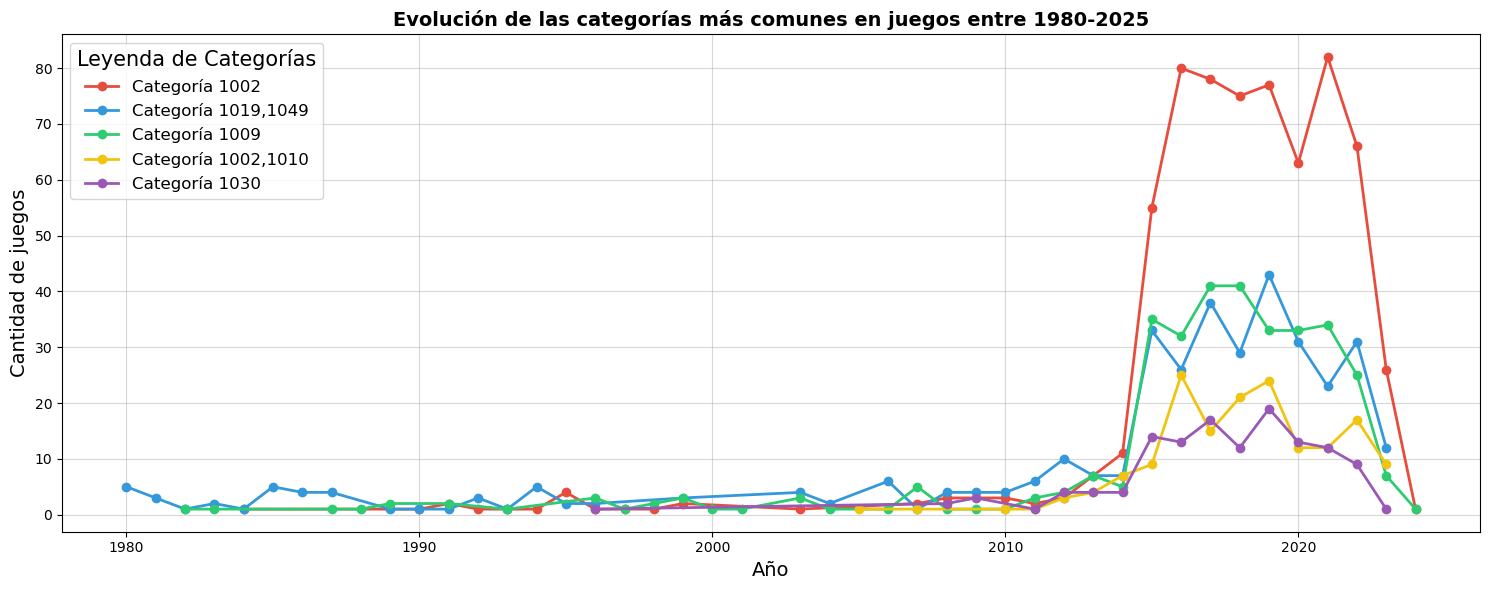

In [59]:
plt.figure(figsize=(15, 6))

# Colores para cada categoría generados con AI
# prompt: Dame un array de 5 colores para luego hacer un plot.
colors = ['#E74C3C',  # Rojo intenso
          '#3498DB',  # Azul brillante
          '#2ECC71',  # Verde vibrante
          '#F1C40F',  # Amarillo fuerte
          '#9B59B6']  # Morado intenso

for idx, category in enumerate(top_5_category_names):
    # Filtramos los datos para esta categoría específica
    category_data = df_top_categories_combined[df_top_categories_combined['Categoría'] == category]
    
    # Ordenamos por año para una línea continua
    category_data = category_data.sort_values('Año')
    
    plt.plot(category_data['Año'], category_data['Cantidad'], 
             marker='o', linewidth=2, color=colors[idx], label=f'Categoría {category}')

plt.title('Evolución de las categorías más comunes en juegos entre 1980-2025', 
          fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=14)
plt.ylabel('Cantidad de juegos', fontsize=14)
plt.legend(title='Leyenda de Categorías', fontsize=12, title_fontsize=15)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

Asumimos que evaluamos el periodo 1980-2025, a causa del filtrado solicitado en celdas anteriores.

Debemos contar la cantidad de juegos en los años 80s y hoy, como lo pide el enunciado, para ello he considerado que los años 80s es la década de los 80s, que está en la variable 'years_80s', y los años de actualidad en la variable 'years_actualidad', que consiste en la última década. No he considerado la actualidad como este último año porque la última década me parece que da más información de la tendencia actual.

In [60]:
years_80s = [1980, 1990]
years_actualidad = [2015, 2025]

# Calculamos el total de juegos por categoría en diferentes períodos
for idx, category in enumerate(top_5_category_names):
    
    # Seleccionamos los datos de la categoría actual y acotamos por la década de los 80s, para después sumar.
    filter_pre_2000 = (
        (df_top_categories_combined['Categoría'] == category) & 
        (df_top_categories_combined['Año'] >= years_80s[0]) & 
        (df_top_categories_combined['Año'] <= years_80s[1])
    )
    
    quantify_games_80s = df_top_categories_combined[filter_pre_2000]['Cantidad'].sum() # Sumamos los datos que pasan el filtro
    
    # Seleccionamos los datos de la categoría actual y acotamos por la década actual, para después sumar.
    filter_post_2000 = (
        (df_top_categories_combined['Categoría'] == category) &
        (df_top_categories_combined['Año'] >= years_actualidad[0]) &
        (df_top_categories_combined['Año'] <= years_actualidad[1])
    )
    
    quantity_games_actualidad = df_top_categories_combined[filter_post_2000]['Cantidad'].sum() # Sumamos los datos que pasan el filtro
    
    print(f"La categoría '{category}' tiene los siguientes datos:")
    print(f"Juegos en la década de los 80s: {quantify_games_80s} juegos")
    print(f"Juegos en la actualidad: {quantity_games_actualidad} juegos")
    print(f"Hay una variación neta de: {quantity_games_actualidad - quantify_games_80s:d} juegos")
    print('='*50, '\n')

La categoría '1002' tiene los siguientes datos:
Juegos en la década de los 80s: 2 juegos
Juegos en la actualidad: 603 juegos
Hay una variación neta de: 601 juegos

La categoría '1019,1049' tiene los siguientes datos:
Juegos en la década de los 80s: 27 juegos
Juegos en la actualidad: 266 juegos
Hay una variación neta de: 239 juegos

La categoría '1009' tiene los siguientes datos:
Juegos en la década de los 80s: 6 juegos
Juegos en la actualidad: 282 juegos
Hay una variación neta de: 276 juegos

La categoría '1002,1010' tiene los siguientes datos:
Juegos en la década de los 80s: 0 juegos
Juegos en la actualidad: 144 juegos
Hay una variación neta de: 144 juegos

La categoría '1030' tiene los siguientes datos:
Juegos en la década de los 80s: 0 juegos
Juegos en la actualidad: 110 juegos
Hay una variación neta de: 110 juegos



Viendo el gráfico, se puede apreciar que existe un cambio abrupto en la cantiadad de juegos publicados para las categorías más populares en la última década, con respecto a todo el periodo anterior graficado. Además, con el cálculo de la variación neta en la celda anterior, se puede ver no solamente que hay una mayor cantidad de juegos publicados en las categorías analizadas, sino que también las categorías más populares en los 80s cambiaron sus posiciones con respecto a la actualidad.

### 3.5 Análisis Crítico (Bono +0.5 puntos)

¿Qué limitaciones o problemas encontraste en los datos?

- Las categorías tienen números para identificarlas, y no queda claro a qué se traduce ese número identificatorio, no queda clara la traducción literal de ese número. Por ejemplo, la categoría '001' podría coincidir con 'estrategia rápida', pero no está en el dataset esa información. Lo mismo ocurre con otros atributos, como el 'publisher' y demás: hay que hacer un esfuerzo extra en buscar esa información en otro lado, no está contenida en el dataset.

- Hay algunos datos con valores nulos o no válidos, porque al filtrar se han reducido la cantidad de rows, como se puede ver en los outputs de las celdas.

- Con respecto a lo anterior, hay un grave problema con datos faltantes de las columnas ya que las siguientes columnas tienen una gran cantidad de datos nulos; bga_id, dbpedia_id, luding_id, spielen_id, wikidata_id, wikipedia_id.

- Una pequeña reflexión: hay una complicación con las categorías, aunque bastante pequeña, y es que algunos juegos pertenecen a más de una categoría y, si un juego pertenece, digamos, a dos categorías, se verán agrupadas en la columna de category como "0001, 0002". El mismo "problema" sucede con otros atributos, como el publisher y demás, por lo que hay que hacer un esfuerzo extra en separar esa agrupación si se quiere trabajarlas por separado.